Phase 4: Handling Class Imbalance

Step 1: Analyze Class Imbalance

In [1]:
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
X_train = pd.read_csv(
    "../data/processed/X_train_scaled.csv"
)

y_train = pd.read_csv(
    "../data/processed/y_train.csv"
)

In [3]:
print("Training Features :", X_train.shape)

print("Training Target :", y_train.shape)

Training Features : (226980, 30)
Training Target : (226980, 1)


In [4]:
y_train.head()

,Class
0,0
1,0
2,0
3,0
4,0


In [5]:
class_counts = y_train["Class"].value_counts()

print(class_counts)

Class
0    226602
1       378
Name: count, dtype: int64


In [6]:
class_percent = (
    y_train["Class"].value_counts(normalize=True)
    * 100
)

print(class_percent)

Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64


In [7]:
distribution = pd.DataFrame({

    "Class": ["Genuine", "Fraud"],

    "Count": class_counts.values,

    "Percentage": class_percent.values

})

distribution

,Class,Count,Percentage
0,Genuine,226602,99.833466
1,Fraud,378,0.166534


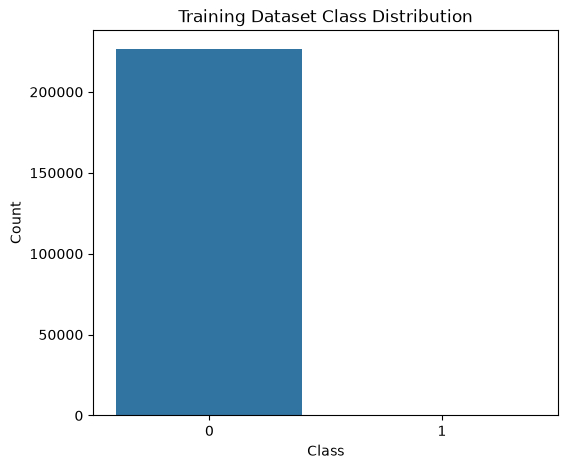

In [8]:
plt.figure(figsize=(6,5))

sns.countplot(
    x=y_train["Class"]
)

plt.title("Training Dataset Class Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.savefig(
    "../images/class_distribution_before_smote.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

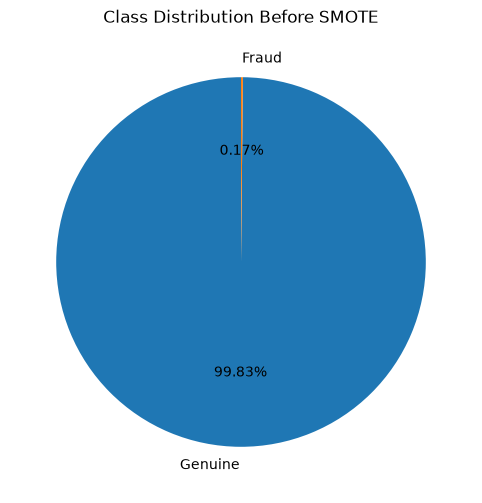

In [9]:
plt.figure(figsize=(6,6))

plt.pie(

    class_counts,

    labels=["Genuine","Fraud"],

    autopct="%1.2f%%",

    startangle=90

)

plt.title("Class Distribution Before SMOTE")

plt.savefig(
    "../images/pie_before_smote.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
majority = class_counts[0]

minority = class_counts[1]

ratio = majority / minority

print(f"Imbalance Ratio : {ratio:.2f}:1")

Imbalance Ratio : 599.48:1


In [11]:
distribution.to_csv(
    "../reports/class_distribution_before_smote.csv",
    index=False
)

In [12]:
summary = pd.DataFrame({

    "Metric":[

        "Majority Class",

        "Minority Class",

        "Imbalance Ratio"

    ],

    "Value":[

        class_counts[0],

        class_counts[1],

        ratio

    ]

})

summary.to_csv(

    "../reports/imbalance_summary.csv",

    index=False

)

Step 2: Apply SMOTE (Synthetic Minority Over-sampling Technique)

In [13]:
import pandas as pd

from imblearn.over_sampling import SMOTE

In [14]:
X_train = pd.read_csv(
    "../data/processed/X_train_scaled.csv"
)

y_train = pd.read_csv(
    "../data/processed/y_train.csv"
)

In [15]:
y_train = y_train.squeeze()

In [16]:
print(type(y_train))

<class 'pandas.Series'>


In [17]:
print(type(y_train))

<class 'pandas.Series'>


In [18]:
smote = SMOTE(
    sampling_strategy="auto",
    random_state=42,
    k_neighbors=5
)

In [19]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [26]:
print("Before SMOTE")

print(X_train.shape)

print(y_train.shape)

print()

print("After SMOTE")

print(X_train_smote.shape)

print(y_train_smote.shape)

Before SMOTE
(226980, 30)
(226980,)

After SMOTE
(453204, 30)
(453204,)


In [21]:
print(y_train_smote.value_counts())

Class
0    226602
1    226602
Name: count, dtype: int64


In [22]:
print(
    y_train_smote.value_counts(normalize=True)*100
)

Class
0    50.0
1    50.0
Name: proportion, dtype: float64


In [23]:
comparison = pd.DataFrame({

    "Before":[226602,378],

    "After":[226602,226602]

},

index=["Genuine","Fraud"])

comparison

,Before,After
Genuine,226602,226602
Fraud,378,226602


In [24]:
comparison = pd.DataFrame({

    "Before":[226602,378],

    "After":[226602,226602]

},

index=["Genuine","Fraud"])

comparison

,Before,After
Genuine,226602,226602
Fraud,378,226602


In [25]:
summary = pd.DataFrame({

    "Metric":[

        "Original Genuine",

        "Original Fraud",

        "Balanced Genuine",

        "Balanced Fraud"

    ],

    "Value":[

        226602,

        378,

        226602,

        226602

    ]

})

summary.to_csv(
    "../reports/smote_summary.csv",
    index=False
)

In [27]:
X_train_smote.to_csv(
    "../data/processed/X_train_smote.csv",
    index=False
)

In [28]:
y_train_smote.to_csv(
    "../data/processed/y_train_smote.csv",
    index=False
)